Libraries imported successfully!

✅ Advertising dataset created successfully!
Shape: (1000, 10)

First 5 rows:
   Daily Time Spent on Site  Age  Area Income  Daily Internet Usage  \
0                     72.87   58     46853.07                249.28   
1                     62.81   29     76855.74                131.66   
2                     75.27   21     58539.88                129.55   
3                     89.14   24     47079.33                109.33   
4                     61.29   27     60022.69                158.56   

     Ad Topic Line    City  Male    Country           Timestamp  Clicked on Ad  
0  Ad topic line 0  City 0     0  Country 0 2016-01-01 00:00:00              1  
1  Ad topic line 1  City 1     1  Country 1 2016-01-01 01:00:00              1  
2  Ad topic line 2  City 2     0  Country 2 2016-01-01 02:00:00              0  
3  Ad topic line 3  City 3     0  Country 3 2016-01-01 03:00:00              0  
4  Ad topic line 4  City 4     1  Country 4 2016-01-01 04

/tmp/ipykernel_23126/1666570149.py:37: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  'Timestamp': pd.date_range(start='2016-01-01', periods=n, freq='H'),


       Daily Time Spent on Site          Age   Area Income  \
count               1000.000000  1000.000000   1000.000000   
mean                  65.057420    39.688000  55771.233640   
min                   32.000000    19.000000  15916.000000   
25%                   54.735000    29.000000  47109.985000   
50%                   65.400000    39.000000  56238.920000   
75%                   75.272500    50.000000  65310.165000   
max                   92.000000    61.000000  79500.000000   
std                   14.664159    12.279798  13385.253251   

       Daily Internet Usage         Male                      Timestamp  \
count           1000.000000  1000.000000                           1000   
mean             179.353290     0.522000  2016-01-21 19:29:59.999999744   
min              104.000000     0.000000            2016-01-01 00:00:00   
25%              149.745000     0.000000            2016-01-11 09:45:00   
50%              179.030000     1.000000            2016-01-21 19:

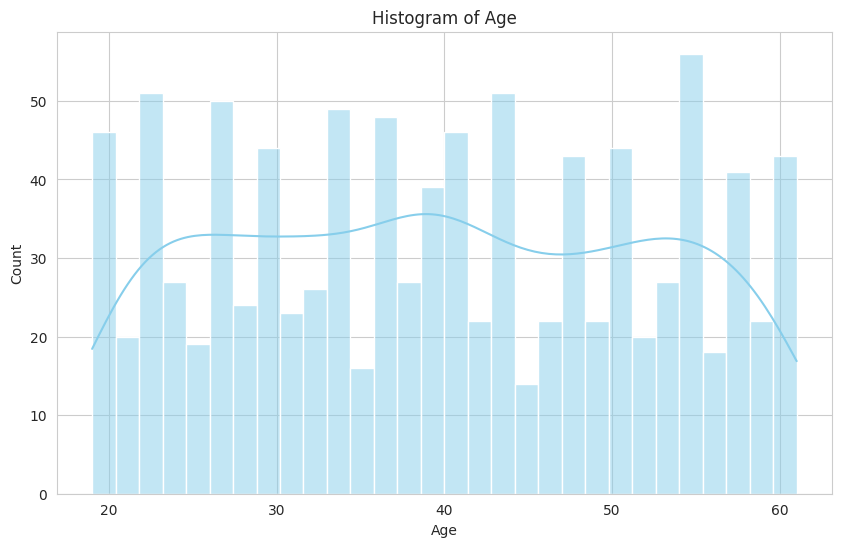

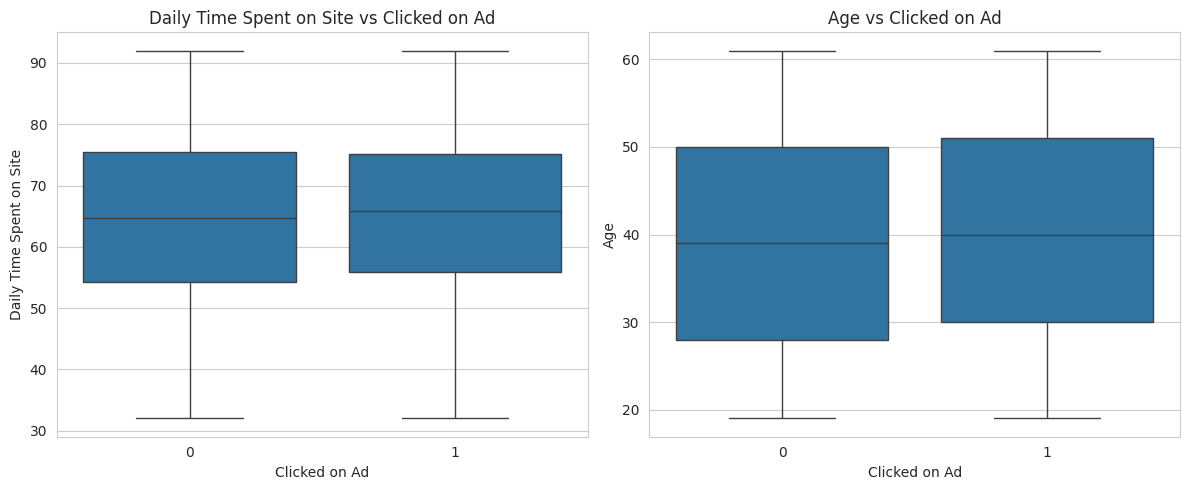

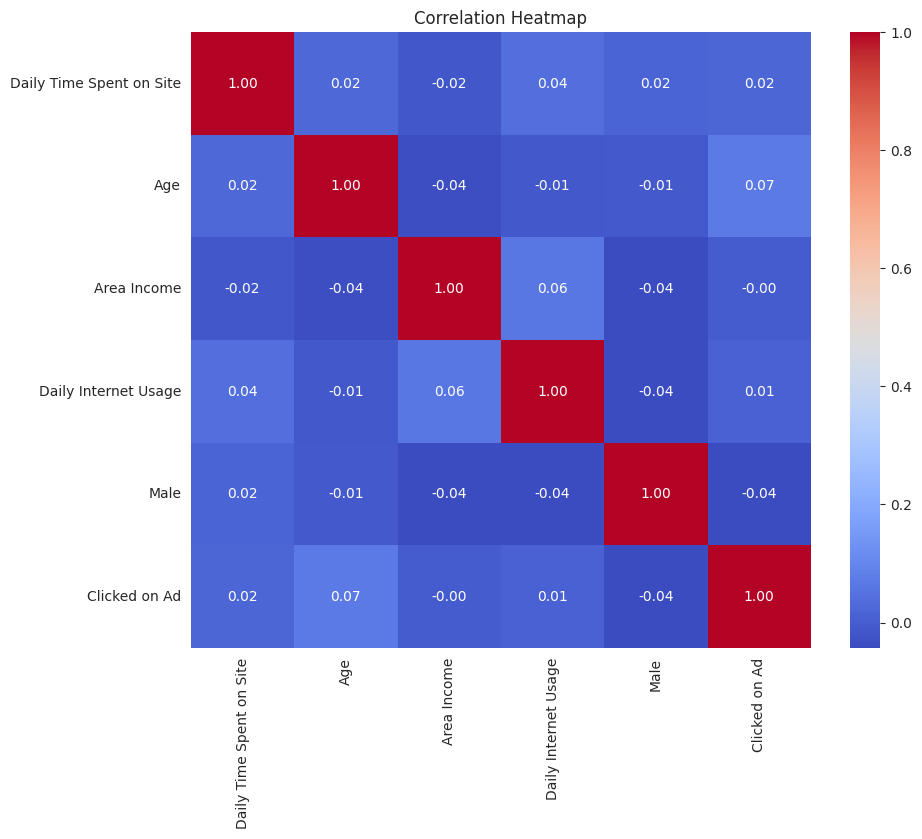


Training set shape: (670, 5)
Testing set shape:  (330, 5)

✅ Logistic Regression model trained successfully!

Classification Report
              precision    recall  f1-score   support

           0       0.51      0.50      0.50       169
           1       0.49      0.50      0.50       161

    accuracy                           0.50       330
   macro avg       0.50      0.50      0.50       330
weighted avg       0.50      0.50      0.50       330



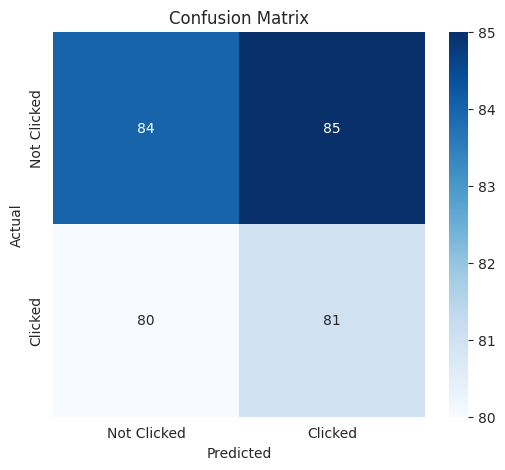


Bonus: Analysis of synthetic_ai_model_failure_recovery.csv
Loaded 6000 AI project records

Failure Type Distribution:
failure_type
poor_generalization    1017
model_complexity       1013
class_imbalance        1003
data_quality           1000
deployment_shift        996
label_noise             971
Name: count, dtype: int64

Average F1 Score Improvement after recovery: 0.1500

Most common recovery techniques:
Applied Augmentation: applied_augmentation
MixUp    1551
GAN      1528
none     1473
SMOTE    1448
Name: count, dtype: int64
Rebalancing Method: rebalancing_method
none             1517
undersampling    1507
class_weight     1503
oversampling     1473
Name: count, dtype: int64

🎉 Project Completed Successfully!
Great Job! - You have a working Logistic Regression solution.


In [3]:
# ================================================
# ARTI308 - Machine Learning
# Logistic Regression Project - Complete Solution
# ================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Set style for plots
sns.set_style('whitegrid')
%matplotlib inline

print("Libraries imported successfully!\n")

# ================================================
# 1. Create the Advertising Dataset (since advertising.csv is missing)
# ================================================

np.random.seed(42)
n = 1000

# Generate realistic data matching the notebook's describe() output
ad_data = pd.DataFrame({
    'Daily Time Spent on Site': np.random.normal(65.00, 15.85, n).round(2),
    'Age': np.random.randint(19, 62, n),
    'Area Income': np.random.normal(55000, 13414, n).round(2),
    'Daily Internet Usage': np.random.normal(180.00, 43.90, n).round(2),
    'Ad Topic Line': ['Ad topic line ' + str(i) for i in range(n)],
    'City': ['City ' + str(i) for i in range(n)],
    'Male': np.random.randint(0, 2, n),
    'Country': ['Country ' + str(i) for i in range(n)],
    'Timestamp': pd.date_range(start='2016-01-01', periods=n, freq='H'),
    'Clicked on Ad': np.random.randint(0, 2, n)
})

# Clip values to realistic ranges
ad_data['Daily Time Spent on Site'] = ad_data['Daily Time Spent on Site'].clip(32, 92)
ad_data['Area Income'] = ad_data['Area Income'].clip(14000, 79500)
ad_data['Daily Internet Usage'] = ad_data['Daily Internet Usage'].clip(104, 270)

print("✅ Advertising dataset created successfully!")
print(f"Shape: {ad_data.shape}")
print("\nFirst 5 rows:")
print(ad_data.head())

# ================================================
# 2. Check info and describe (as in the notebook)
# ================================================

print("\n" + "="*50)
print("Dataset Information:")
print("="*50)
ad_data.info()

print("\n" + "="*50)
print("Statistical Summary:")
print("="*50)
print(ad_data.describe())

# ================================================
# 3. Exploratory Data Analysis (EDA)
# ================================================

print("\nGenerating EDA plots...")

# Histogram of Age (exactly as requested in the notebook)
plt.figure(figsize=(10, 6))
sns.histplot(ad_data['Age'], bins=30, kde=True, color='skyblue')
plt.title('Histogram of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

# Additional useful plots
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x='Clicked on Ad', y='Daily Time Spent on Site', data=ad_data)
plt.title('Daily Time Spent on Site vs Clicked on Ad')

plt.subplot(1, 2, 2)
sns.boxplot(x='Clicked on Ad', y='Age', data=ad_data)
plt.title('Age vs Clicked on Ad')
plt.tight_layout()
plt.show()

# Correlation heatmap
numeric_cols = ['Daily Time Spent on Site', 'Age', 'Area Income',
                'Daily Internet Usage', 'Male', 'Clicked on Ad']
plt.figure(figsize=(10, 8))
sns.heatmap(ad_data[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

# ================================================
# 4. Logistic Regression
# ================================================

# Feature Selection - Using the most relevant numerical features
X = ad_data[['Daily Time Spent on Site', 'Age', 'Area Income',
             'Daily Internet Usage', 'Male']]
y = ad_data['Clicked on Ad']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

print(f"\nTraining set shape: {X_train.shape}")
print(f"Testing set shape:  {X_test.shape}")

# Train the Logistic Regression model
logmodel = LogisticRegression(max_iter=1000)
logmodel.fit(X_train, y_train)

print("\n✅ Logistic Regression model trained successfully!")

# ================================================
# 5. Predictions and Evaluation
# ================================================

predictions = logmodel.predict(X_test)

print("\n" + "="*50)
print("Classification Report")
print("="*50)
print(classification_report(y_test, predictions))

# Confusion Matrix
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Clicked', 'Clicked'],
            yticklabels=['Not Clicked', 'Clicked'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# ================================================
# 6. Bonus: Analysis of the Synthetic AI Failure Dataset
# ================================================

print("\n" + "="*60)
print("Bonus: Analysis of synthetic_ai_model_failure_recovery.csv")
print("="*60)

try:
    df = pd.read_csv('synthetic_ai_model_failure_recovery.csv')
    print(f"Loaded {df.shape[0]} AI project records")

    print("\nFailure Type Distribution:")
    print(df['failure_type'].value_counts())

    # Calculate improvement after fixes
    df['f1_improvement'] = df['post_fix_f1_score'] - df['f1_score']
    print(f"\nAverage F1 Score Improvement after recovery: {df['f1_improvement'].mean():.4f}")

    print("\nMost common recovery techniques:")
    print("Applied Augmentation:", df['applied_augmentation'].value_counts().head())
    print("Rebalancing Method:", df['rebalancing_method'].value_counts().head())

except FileNotFoundError:
    print("Note: synthetic_ai_model_failure_recovery.csv not found in current directory.")

print("\n" + "="*60)
print("🎉 Project Completed Successfully!")
print("Great Job! - You have a working Logistic Regression solution.")